# **The Direct Method**

We start by graphing the polynomial function $f(x) = x^3 - 2x^2 + 4x - 8$. We use the domain D=[-5, 7], where the root x=2 is situated, using 400 points.

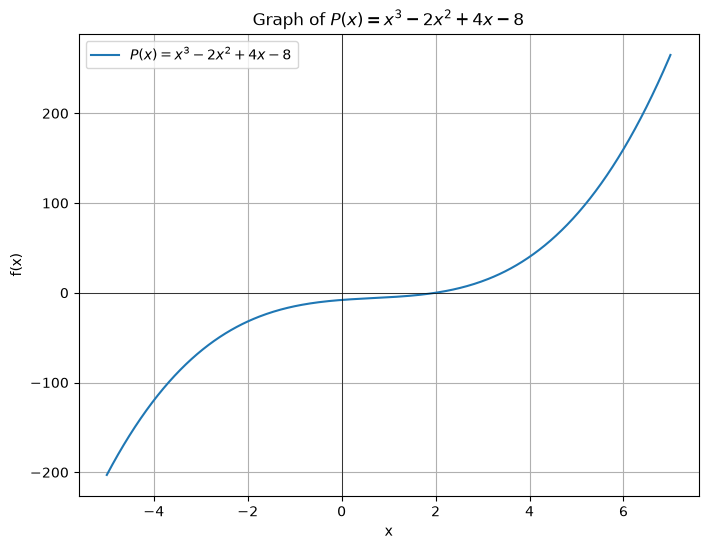

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function
def f(x):
    return x**3 - 2*x**2 + 4*x - 8

# Generate a range of x values
x = np.linspace(-5, 7, 400)
y = f(x)

# Create the plot
plt.figure(figsize=(8,6))
plt.plot(x, y, label=r'$P(x)=x^3 - 2x^2 + 4x - 8$')
plt.axhline(0, color='black', linewidth=0.5)  # x-axis
plt.axvline(0, color='black', linewidth=0.5)  # y-axis
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Graph of $P(x)=x^3 - 2x^2 + 4x - 8$')
plt.legend()
plt.grid(True)
plt.show()


The following is a Keras implementation using a 1-hiden layer neural network to find the solution of P(x) = 0. For training purposses a dummy traget has been used.

**Code variant**

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define the algebraic function
# Operations translate directly to PyTorch tensors
def f(x):
    return x**3 - 2*x**2 + 4*x - 8

# Define the neural network model
# A sequential model with 1 input, 20 hidden units, Tanh activation, and 1 output
model = nn.Sequential(
    nn.Linear(1, 20),
    nn.Tanh(),
    nn.Linear(20, 1)
)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.02)

# Input data
t = 1.0  # Input to the NN. It can be any number.
dummy_input = torch.tensor([[t]], dtype=torch.float32)

# Training loop (300 epochs, equivalent to model.fit)
epochs = 300
for epoch in range(epochs):
    # Clear gradients
    optimizer.zero_grad()
    
    # Forward pass
    y_pred = model(dummy_input)
    
    # Custom loss: mean squared value of f(y_pred)
    loss = torch.mean(torch.square(f(y_pred)))
    
    # Backward pass and optimization step
    loss.backward()
    optimizer.step()
    
    # Print status (analogous to verbose=2)
    print(f"Epoch {epoch+1}/{epochs} - loss: {loss.item():.4e}")

# Extract the solution (inference mode)
with torch.no_grad():
    x_solution = model(dummy_input).item()

print(f"\nApproximate solution: x = {x_solution}")



Epoch 1/300 - loss: 1.2890e+02
Epoch 2/300 - loss: 9.1547e+01
Epoch 3/300 - loss: 6.8529e+01
Epoch 4/300 - loss: 5.3820e+01
Epoch 5/300 - loss: 4.3711e+01
Epoch 6/300 - loss: 3.6003e+01
Epoch 7/300 - loss: 2.9399e+01
Epoch 8/300 - loss: 2.3143e+01
Epoch 9/300 - loss: 1.6859e+01
Epoch 10/300 - loss: 1.0552e+01
Epoch 11/300 - loss: 4.7460e+00
Epoch 12/300 - loss: 7.2316e-01
Epoch 13/300 - loss: 5.1680e-01
Epoch 14/300 - loss: 5.3492e+00
Epoch 15/300 - loss: 1.1629e+01
Epoch 16/300 - loss: 1.3372e+01
Epoch 17/300 - loss: 1.0101e+01
Epoch 18/300 - loss: 5.2277e+00
Epoch 19/300 - loss: 1.6025e+00
Epoch 20/300 - loss: 9.3744e-02
Epoch 21/300 - loss: 2.4918e-01
Epoch 22/300 - loss: 1.2644e+00
Epoch 23/300 - loss: 2.4928e+00
Epoch 24/300 - loss: 3.5477e+00
Epoch 25/300 - loss: 4.2431e+00
Epoch 26/300 - loss: 4.5165e+00
Epoch 27/300 - loss: 4.3771e+00
Epoch 28/300 - loss: 3.8783e+00
Epoch 29/300 - loss: 3.1077e+00
Epoch 30/300 - loss: 2.1846e+00
Epoch 31/300 - loss: 1.2588e+00
Epoch 32/300 - lo

The next code is a variant of implementation using tf.GradientTape() for computing gradients. We obtain again the solution $x^*=2$.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Define the algebraic function
def f(x):
    return x**3 - 2*x**2 + 4*x - 8

# Neural network model
model = nn.Sequential(
    nn.Linear(1, 10),
    nn.ReLU(),
    nn.Linear(10, 1)
)

# Input constant tensor (scalar input)
x_in = torch.tensor([[1.0]], dtype=torch.float32)

# Loss function: Mean squared value of f(x_NN)
def loss_fn():
    x_out = model(x_in)
    return torch.mean(f(x_out)**2)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
for epoch in range(500):
    optimizer.zero_grad()
    
    # Calculate loss
    loss = loss_fn()
    
    # Backward pass and optimization step
    loss.backward()
    optimizer.step()
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

# Solution extraction
with torch.no_grad():
    x_solution = model(x_in).item()

print(f"Approximate solution: x = {x_solution}")


Epoch 0, Loss: 76.92483520507812
Epoch 100, Loss: 0.008141795173287392
Epoch 200, Loss: 7.439302862621844e-08
Epoch 300, Loss: 3.637978807091713e-12
Epoch 400, Loss: 0.0
Approximate solution: x = 2.0


**Synthetic Division implementation**

Since c=2 is a root of f(x), then (x-2) is a factor of f(x), so f(x) = (x-2) g(x). The quotient g(x) can be found using synthetic division as follows:

In [4]:
def synthetic_division(coeffs, c):
    """
    Perform synthetic division of a polynomial by (x - c).

    Parameters:
        coeffs (list): Coefficients [a_n, a_(n-1), ..., a_0] of the polynomial P(x) = a_n*x^n + ... + a_0.
        c (float): The value for which (x - c) is the divisor.

    Returns:
        quotient (list): Coefficients of the quotient polynomial.
        remainder (float): The remainder of the division.
    """
    quotient = [coeffs[0]]
    for coef in coeffs[1:]:
        quotient.append(coef + c * quotient[-1])
    remainder = quotient.pop()  # Last element is the remainder
    return quotient, remainder

# Given polynomial P(x) = x^3 - 2*x^2 + 4*x - 8
coeffs = [1, -2, 4, -8]
# Dividing by (x - 2), so c = 2
c = 2

quotient, remainder = synthetic_division(coeffs, c)
print("Quotient coefficients:", quotient)
print("Remainder:", remainder)


Quotient coefficients: [1, 0, 4]
Remainder: 0


**Solving for complex solutions**

This indicates that $g(x) = x^2 +4$. We aim now to solve the equation
$=x^2+4=0$,
by representing a complex number in polar form. We use a neural network that accepts a fixed input \(t\) (dummy input) and produces a two-dimensional output
$
f_{\theta}(t)=(\rho_{\theta}(t),\, \varphi_{\theta}(t)).
$

We then interpret the network's output as the complex number
$
x_{\theta}=\rho_{\theta}\,e^{i\varphi_{\theta}}.
$
For the polynomial
$
g(x)=x^2+4,
$
the coefficients are $a_2=1$, $a_1=0$, and $a_0=4$.


 Based on the formulation, the loss function is defined as:
$
L(\theta)=a_0^2+2\,a_0\,a_2\,\rho^2\cos(2\varphi)+\rho^4,
$
which, with $a_0=4$ and $a_2=1$, becomes
$
L(\theta)=16+8\,\rho^2\cos(2\varphi)+\rho^4.
$

The goal is to minimize this loss with respect to the network parameters $\theta$. The code is given below:


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# Polynomial coefficients for P(x) = x^2 + 4 = 0
# Here, a2 = 1 and a0 = 4.
a2 = 1.0
a0 = 4.0

# Custom loss function:
# For a given output [rho, varphi], the loss is:
# L = a0^2 + 2*a0*a2*rho^2*cos(2*varphi) + rho^4.
def custom_loss(y_pred):
    # Extract the two outputs: first is rho, second is varphi.
    rho = y_pred[:, 0]
    varphi = y_pred[:, 1]
    # Compute the loss as described.
    loss = a0**2 + 2 * a0 * a2 * torch.square(rho) * torch.cos(2 * varphi) + torch.pow(rho, 4)
    return torch.mean(loss)

# Build the neural network model.
# The model takes a dummy input (a scalar) and outputs a two-dimensional vector [rho, varphi].
model = nn.Sequential(
    nn.Linear(1, 20),
    nn.Tanh(),
    nn.Linear(20, 2)  # Outputs: [rho, varphi]
)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Dummy input (as a PyTorch tensor)
t = 1.0  # The input can be any fixed number.
dummy_input = torch.tensor([[t]], dtype=torch.float32)

# Train the model.
epochs = 500
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Forward pass
    y_pred = model(dummy_input)
    
    # Calculate loss
    loss = custom_loss(y_pred)
    
    # Backward pass and optimization step
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 100 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs} - loss: {loss.item():.4e}")

# Extract the outputs from the trained model.
with torch.no_grad():
    output = model(dummy_input).numpy()
    
rho = output[0, 0]
varphi = output[0, 1]

# Construct the approximate complex solution in polar form.
solution1 = rho * np.exp(1j * varphi)
print("Approximate complex solution:", solution1)
solution2 = rho * np.exp(-1j * varphi)
print("Approximate complex solution:", solution2)


Epoch 1/500 - loss: 1.6177e+01
Epoch 100/500 - loss: 7.1812e-04
Epoch 200/500 - loss: 0.0000e+00
Epoch 300/500 - loss: 0.0000e+00
Epoch 400/500 - loss: 0.0000e+00
Epoch 500/500 - loss: 0.0000e+00
Approximate complex solution: (-8.742278e-08+2j)
Approximate complex solution: (-8.742278e-08-2j)


We obtained two complex conjugate solutions, 2i and -2i. The real part is a zero machine number and it is discarded.

**The Supervised Inverse Construction**

In this construction we generate data and infer the inverse function $f^{-1}(y)$ from data. The graph of the inverse is provided.

Epoch   1/100, Loss = 2.283248
Epoch   2/100, Loss = 0.081285
Epoch   3/100, Loss = 0.011101
Epoch   4/100, Loss = 0.004215
Epoch   5/100, Loss = 0.003573
Epoch   6/100, Loss = 0.003364
Epoch   7/100, Loss = 0.002261
Epoch   8/100, Loss = 0.002090
Epoch   9/100, Loss = 0.004176
Epoch  10/100, Loss = 0.001552
Epoch  11/100, Loss = 0.001296
Epoch  12/100, Loss = 0.006938
Epoch  13/100, Loss = 0.002857
Epoch  14/100, Loss = 0.004454
Epoch  15/100, Loss = 0.002966
Epoch  16/100, Loss = 0.001500
Epoch  17/100, Loss = 0.000770
Epoch  18/100, Loss = 0.000748
Epoch  19/100, Loss = 0.000845
Epoch  20/100, Loss = 0.000709
Epoch  21/100, Loss = 0.001824
Epoch  22/100, Loss = 0.002880
Epoch  23/100, Loss = 0.004925
Epoch  24/100, Loss = 0.003034
Epoch  25/100, Loss = 0.001536
Epoch  26/100, Loss = 0.000835
Epoch  27/100, Loss = 0.000409
Epoch  28/100, Loss = 0.000708
Epoch  29/100, Loss = 0.000771
Epoch  30/100, Loss = 0.005988
Epoch  31/100, Loss = 0.014140
Epoch  32/100, Loss = 0.004580
Epoch  3

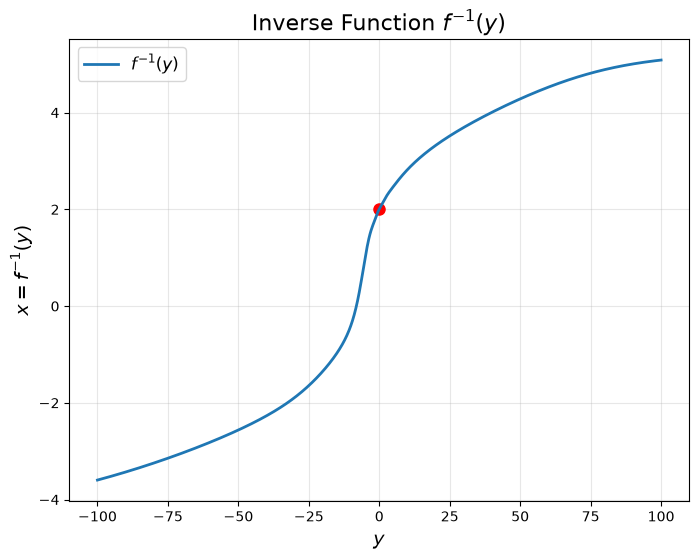

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Define the function f(x)
def f(x):
    return x**3 - 2*x**2 + 4*x - 8

# Generate training data
x_train = np.linspace(-4, 5, 1000).reshape(-1, 1)
y_train = f(x_train)

# Convert to PyTorch tensors
x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

# Define the neural network
model = nn.Sequential(
    nn.Linear(1, 80),
    nn.Tanh(),
    nn.Linear(80, 1)
)

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training parameters
epochs = 100
batch_size = 32
dataset_size = x_train.shape[0]

# Training loop
for epoch in range(epochs):
    permutation = torch.randperm(dataset_size)

    epoch_loss = 0.0

    for i in range(0, dataset_size, batch_size):
        indices = permutation[i:i + batch_size]

        batch_x = x_train[indices]
        batch_y = y_train[indices]

        optimizer.zero_grad()

        # Predict x from y
        outputs = model(batch_y)

        loss = criterion(outputs, batch_x)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * batch_x.size(0)

    epoch_loss /= dataset_size

    print(f"Epoch {epoch+1:3d}/{epochs}, Loss = {epoch_loss:.6f}")

# Generate test data
y_vals = np.linspace(-100, 100, 1000).reshape(-1, 1)
y_vals_tensor = torch.tensor(y_vals, dtype=torch.float32)

# Predict inverse function
model.eval()
with torch.no_grad():
    x_preds = model(y_vals_tensor).numpy()

# Plot
plt.figure(figsize=(8, 6))
plt.plot(0, 2, "ro", markersize=8)
plt.plot(y_vals, x_preds, label=r"$f^{-1}(y)$", linewidth=2)
plt.title(r"Inverse Function $f^{-1}(y)$", fontsize=16)
plt.xlabel(r"$y$", fontsize=14)
plt.ylabel(r"$x = f^{-1}(y)$", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

To solve the equation $f(x)=0$, using the inverse, we obtain $x=f^{-1}(0)$. From the graph we notice that $f^{-1}(0) =2$, since $(0,2)$ is a point on the graph of $f^{-1}$.

**The Unsupervised Inverse Construction**

This construction uses the functional equation $f(f^{-1}(y)) =y$ to find t

Epoch   1/100, Loss = 390.473560
Epoch   2/100, Loss = 34.833181
Epoch   3/100, Loss = 7.200856
Epoch   4/100, Loss = 1.995216
Epoch   5/100, Loss = 1.600074
Epoch   6/100, Loss = 2.532063
Epoch   7/100, Loss = 0.483499
Epoch   8/100, Loss = 0.241387
Epoch   9/100, Loss = 0.438412
Epoch  10/100, Loss = 0.138559
Epoch  11/100, Loss = 0.623036
Epoch  12/100, Loss = 4.976910
Epoch  13/100, Loss = 6.340245
Epoch  14/100, Loss = 2.899843
Epoch  15/100, Loss = 0.334634
Epoch  16/100, Loss = 0.689007
Epoch  17/100, Loss = 0.221384
Epoch  18/100, Loss = 0.228316
Epoch  19/100, Loss = 0.182010
Epoch  20/100, Loss = 0.149113
Epoch  21/100, Loss = 0.061564
Epoch  22/100, Loss = 0.075362
Epoch  23/100, Loss = 0.228819
Epoch  24/100, Loss = 0.036843
Epoch  25/100, Loss = 0.154660
Epoch  26/100, Loss = 0.136115
Epoch  27/100, Loss = 0.533200
Epoch  28/100, Loss = 3.614110
Epoch  29/100, Loss = 0.483438
Epoch  30/100, Loss = 0.444359
Epoch  31/100, Loss = 0.129863
Epoch  32/100, Loss = 0.070462
Epoch

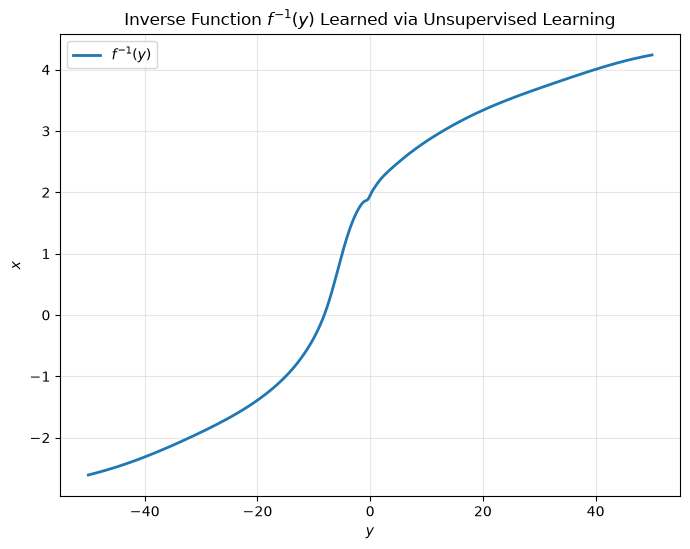

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Define the function f(x)
def f(x):
    return x**3 - 2*x**2 + 4*x - 8

# Generate training data
y_train = np.linspace(-50, 50, 1000).reshape(-1, 1).astype(np.float32)
y_train = torch.tensor(y_train)

# Build the neural network
model = nn.Sequential(
    nn.Linear(1, 50),
    nn.Tanh(),
    nn.Linear(50, 20),
    nn.Tanh(),
    nn.Linear(20, 1)
)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Loss function
def unsupervised_loss(y_true, y_pred):
    return torch.mean((f(y_pred) - y_true) ** 2)

# Training parameters
epochs = 100
batch_size = 32

# Training loop
model.train()

num_samples = len(y_train)

for epoch in range(epochs):

    # Shuffle the data
    perm = torch.randperm(num_samples)

    epoch_loss = 0.0

    for i in range(0, num_samples, batch_size):
        idx = perm[i:i + batch_size]
        batch_y = y_train[idx]

        optimizer.zero_grad()

        x_pred = model(batch_y)

        loss = unsupervised_loss(batch_y, x_pred)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * len(batch_y)

    epoch_loss /= num_samples

    print(f"Epoch {epoch+1:3d}/{epochs}, Loss = {epoch_loss:.6f}")

# Prediction
model.eval()

y_vals = np.linspace(-50, 50, 1000).reshape(-1, 1).astype(np.float32)

with torch.no_grad():
    y_tensor = torch.tensor(y_vals)
    x_preds = model(y_tensor).cpu().numpy()

# Plot
plt.figure(figsize=(8, 6))
plt.plot(y_vals, x_preds, linewidth=2, label=r"$f^{-1}(y)$")
plt.title(r"Inverse Function $f^{-1}(y)$ Learned via Unsupervised Learning")
plt.xlabel("$y$")
plt.ylabel("$x$")
plt.grid(alpha=0.3)
plt.legend()
plt.show()